# 2 Calibration Parameters Problem

In [1]:
from jax import config
config.update("jax_enable_x64", True)

# from data.dataloader import DataLoader
from kohgpjax.mappings import mapRto01, map01toR, mapRto0inf, map0inftoR
from jax import jit, grad, value_and_grad, vmap

import jax.numpy as jnp
import gpjax as gpx
from kohgpjax.base import AbstractKOHModel

import numpy as np
import matplotlib.pyplot as plt

import mici
import arviz

from scipy.stats import gamma

from data.truefuncs import sin1_2_simple as truefunc

plot_style = {
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'axes.linewidth': 0.5,
    'lines.linewidth': 0.5,
    'axes.labelpad': 2.,
    'figure.dpi': 150,
}

## The KOH Model

In [2]:
class Sin1_2(AbstractKOHModel):
    def k_eta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.ProductKernel(
            kernels=[
                gpx.kernels.RBF( # x0
                    active_dims=[0],
                    lengthscale=jnp.array(ells[0]),
                    variance=jnp.array(1/lambdas[0])
                ), 
                gpx.kernels.RBF( # theta0
                    active_dims=[1],
                    lengthscale=jnp.array(ells[1]),
                ),
                gpx.kernels.RBF( # theta1
                    active_dims=[2],
                    lengthscale=jnp.array(ells[2]),
                )
            ]
        )
    
    def k_delta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.RBF(
                active_dims=[0],
                lengthscale=jnp.array(ells[3]),
                variance=jnp.array(1/lambdas[1])
            )

    
    def k_epsilon(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.White(
                active_dims=[0],
                variance=jnp.array(1/lambdas[2])
            )
    
    def k_epsilon_eta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.White(
                active_dims=[0],
                variance=jnp.array(1/lambdas[3])
            )


    def KOH_log_prior(
        self,
        GPJAX_params,
    ):
        thetas, ells, lambdas = GPJAX_params

        ####### ell #######
        # % Prior for ell_eta
        # % EXAMPLE: ell_eta_0 ~ GAM(4,1.4) where 2nd param is rate
        logprior = (4-1)*jnp.log(ells[0]) - 1.4*ells[0]
        # % Prior for ell_eta_1 ~ GAM(2,3.5) where 2nd param is rate
        logprior += (2-1)*jnp.log(ells[1]) - 3.5*ells[1]
        # % Prior for ell_eta_2 ~ GAM(2,2) where 2nd param is rate
        logprior += (2-1)*jnp.log(ells[2]) - 2*ells[2]
        # # % Prior for ell_delta_0 ~ GAM(4,2) where 2nd param is rate
        logprior += (4-1)*jnp.log(ells[3]) - 2*ells[3] # encourage smaller lengthscales on the discrepancy term


        ####### lambda #######
        # % Prior for lambda_eta
        # % EXAMPLE: lambda_eta ~ GAM(2,4) where 2nd param is rate
        # logprior += (2-1)*jnp.log(lambdas[0]) - 4*lambdas[0]
        # % EXAMPLE: lambda_eta ~ GAM(10,10) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[0]) - 10*lambdas[0]

        # % Prior for lambda_b
        # % EXAMPLE: lambda_b ~ GAM(2,0.1) where 2nd param is rate
        # logprior += (2-1)*jnp.log(lambdas[1]) - 0.1*lambdas[1]
        # % EXAMPLE: lambda_b ~ GAM(10,0.3) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[1]) - 0.3*lambdas[1]

        # % Prior for lambda_e
        # % EXAMPLE: lambda_e ~ GAM(12,0.025) where 2nd param is rate
        # logprior += (12-1)*jnp.log(lambdas[2]) - 0.025*lambdas[2]
        # % EXAMPLE: lambda_e ~ GAM(10,0.03) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[2]) - 0.03*lambdas[2]

        # % Prior for lambda_en
        # % EXAMPLE: lambda_en ~ GAM(10,0.001) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[3]) - 0.001*lambdas[3]

        return logprior

## Load data

In [3]:
class DataLoader:
    def __init__(
        self, 
        data_field_path: str, 
        data_comp_path: str
    ):
        DATAFIELD = np.loadtxt(data_field_path, delimiter=',', dtype=np.float32)
        DATACOMP = np.loadtxt(data_comp_path, delimiter=',', dtype=np.float32)

        self.yf = np.reshape(DATAFIELD[:, 0], (-1,1))
        self.yc = np.reshape(DATACOMP[:, 0], (-1,1))
        self.xf = np.reshape(DATAFIELD[:, 1], (-1, 1))
        self.xc = np.reshape(DATACOMP[:, 1], (-1,1))
        self.tc = np.reshape(DATACOMP[:, 2:], (-1,2))

        #Standardize full response using mean and std of yc
        self.yc_mean = np.mean(self.yc)

        self.t_min = np.min(self.tc, axis=0)
        self.t_max = np.max(self.tc, axis=0)

        self.yc_centered = self.yc - self.yc_mean
        self.yf_centered = self.yf - self.yc_mean

        self.tc_normalized = (self.tc - self.t_min)/(self.t_max - self.t_min)

        self.x_stack = jnp.vstack((self.xf, self.xc), dtype=np.float64)
        self.y = jnp.vstack((self.yf_centered, self.yc_centered), dtype=np.float64)

    def get_data(self):
        return self.x_stack, self.tc_normalized, self.y
        # return self.x_stack, self.tc, self.y

    def transform_y(self, y):
        return y - self.yc_mean

    def inverse_transform_y(self, y):
        return y + self.yc_mean

In [4]:
dataloader = DataLoader(
    'data/toy/field_sin1_2_simple_growing.csv', 
    'data/toy/sim_sin1_2_simple_growing.csv'
)
data = dataloader.get_data()
model = Sin1_2(*data)

tmax = dataloader.t_max
tmin = dataloader.t_min

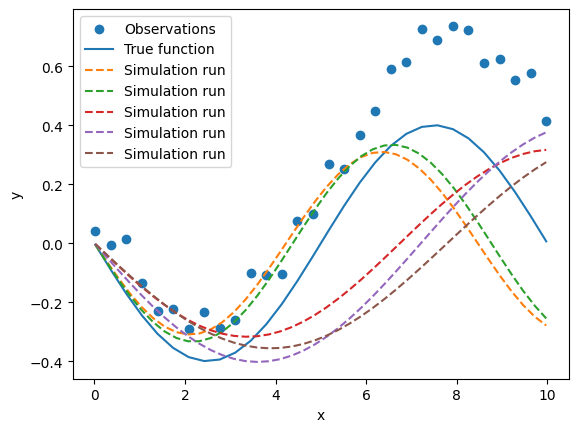

In [5]:
fig, ax = plt.subplots(1, 1)
ax.scatter(dataloader.xf, dataloader.yf, label='Observations')
ax.plot(dataloader.xf, truefunc(dataloader.xf), label='True function')
rng = np.random.default_rng()
ts = rng.permutation(np.unique(dataloader.tc[:,0]))[:5]
for t in ts:
    rows = dataloader.tc[:,0]==t
    ax.plot(dataloader.xc[rows], dataloader.yc[rows], '--', label=f'Simulation run')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

## MCMC Setup

In [6]:
theta_0 = 0.5
theta_1 = 0.25

# ell_eta_0_0 = 1 # np.sqrt(np.var(dataloader.xf))/3
# ell_eta_1_1 = 0.3
# ell_eta_1_2 = 0.3
# ell_delta_0_0 = 1 # np.sqrt(np.var(dataloader.xf))/5

ell_eta_0_0 = 2 # np.sqrt(np.var(dataloader.xf))/3
ell_eta_1_1 = 0.2
ell_eta_1_2 = 0.2
ell_delta_0_0 = 3 # np.sqrt(np.var(dataloader.xf))/5

lambda_eta_0 = 1
lambda_delta_0 = 30
lambda_epsilon_0 = 400
lambda_epsilon_eta_0 = 10000

init_states = np.array([[
    map01toR(theta_0), 
    map01toR(theta_1),
    map0inftoR(ell_eta_0_0),
    map0inftoR(ell_eta_1_1),
    map0inftoR(ell_eta_1_2),
    map0inftoR(ell_delta_0_0),
    map0inftoR(lambda_eta_0),
    map0inftoR(lambda_delta_0),
    map0inftoR(lambda_epsilon_0),
    map0inftoR(lambda_epsilon_eta_0),
]])

In [7]:
def param_transform_mici_to_gpjax(x):
    theta, d_theta = vmap(value_and_grad(mapRto01))(x[0:2])
    ell, d_ell = vmap(value_and_grad(mapRto0inf))(x[2:6])
    lambda_, d_lambda = vmap(value_and_grad(mapRto0inf))(x[6:10])
    return (
        [list(v) for v in (theta, ell, lambda_)], 
        sum(jnp.log(abs(d)).sum() for d in (d_theta, d_ell, d_lambda))
    )

In [8]:
neg_log_posterior_density = model.get_KOH_neg_log_pos_dens_func(
    param_transform_mici_to_gpjax
)
system = mici.systems.EuclideanMetricSystem(
    neg_log_dens=neg_log_posterior_density,
    grad_neg_log_dens=lambda q: q*0,
    backend="jax"
)
integrator = mici.integrators.LeapfrogIntegrator(system)

## Running MCMC algorithm

In [9]:
seed = 1234
n_chain = 2
n_warm_up_iter = 5000
n_main_iter = 10000
rng = np.random.default_rng(seed)

##### Mici sampler and adapters #####
sampler = mici.samplers.StaticMetropolisHMC(system, integrator, rng, n_step=1)
# sampler = mici.samplers.StaticMetropolisHMC(system, integrator, rng, n_step=3)
# sampler = mici.samplers.DynamicMultinomialHMC(system, integrator, rng)
adapters = [
    # mici.adapters.DualAveragingStepSizeAdapter(0.8),
    mici.adapters.DualAveragingStepSizeAdapter(0.234),
    mici.adapters.OnlineCovarianceMetricAdapter()
]

def trace_func(state):
    return {
        'm_theta_0': state.pos[0], 
        'm_theta_1': state.pos[1],
        'm_ell_eta_0': state.pos[2], 
        'm_ell_eta_1': state.pos[3],
        'm_ell_eta_2': state.pos[4],
        'm_ell_delta_0': state.pos[5],
        'm_lambda_eta': state.pos[6],
        'm_lambda_delta': state.pos[7],
        'm_lambda_epsilon': state.pos[8],
        'm_lambda_epsilon_eta': state.pos[9],
        'hamiltonian': system.h(state)
    }

final_states, traces, stats = sampler.sample_chains(
    n_warm_up_iter, 
    n_main_iter, 
    [init_states[0]] * n_chain, 
    adapters=adapters, 
    n_process=1, # only 1 works on MacOS
    trace_funcs=[trace_func],
    monitor_stats=("accept_stat", "step_size")
)

Sampling stage: Initial fast adaptive [00:08] > Slow adaptive (1/7) [00:03] > Slow adaptive (2/7) [00:06] > Slow adaptive (3/7) [00:11] > Slow adaptive (4/7) [00:27] > Slow adaptive (5/7) [01:12] > Slow adaptive (6/7) [03:30] > Slow adaptive (7/7) [12:46] > Final fast adaptive [00:07] > Main non-adaptive [28:28]

Chain 1/2: 100%|██████████|10000/10000 [16:26<00:00, 10.13it/s, accept_stat=0.132, step_size=0.959]

Chain 2/2: 100%|██████████|10000/10000 [12:01<00:00, 13.85it/s, accept_stat=0.139, step_size=0.959]

## Analyse the raw MCMC chains

In [10]:
arviz.summary(traces)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hamiltonian,-3873.734,3.295,-3879.470,-3867.415,0.142,0.090,545.0,1065.0,1.00
m_ell_delta_0,1.243,0.291,0.697,1.808,0.017,0.008,300.0,461.0,1.01
m_ell_eta_0,1.121,0.037,1.051,1.193,0.002,0.001,568.0,877.0,1.01
m_ell_eta_1,1.417,0.114,1.196,1.618,0.006,0.003,393.0,691.0,1.00
m_ell_eta_2,-0.491,0.051,-0.588,-0.396,0.002,0.001,446.0,673.0,1.01
m_lambda_delta,3.438,0.293,2.895,3.979,0.016,0.007,363.0,716.0,1.00
m_lambda_epsilon,5.976,0.216,5.560,6.383,0.009,0.006,586.0,840.0,1.01
m_lambda_epsilon_eta,12.791,0.053,12.696,12.893,0.003,0.001,361.0,752.0,1.00
m_lambda_eta,0.316,0.231,-0.106,0.753,0.011,0.006,416.0,583.0,1.00
m_theta_0,-0.610,1.679,-3.588,2.811,0.087,0.075,386.0,487.0,1.01


In [11]:
for var, trace in traces.items():
    print(var, ": ", np.mean(trace[0]), '±', np.std(trace[0]))

m_theta_0 :  -0.7094120294505457 ± 1.6636162202444462
m_theta_1 :  -0.05515541300380181 ± 0.30885304822019216
m_ell_eta_0 :  1.1217027686325032 ± 0.03572612785474146
m_ell_eta_1 :  1.4219103112617717 ± 0.11550599061152747
m_ell_eta_2 :  -0.4925080678499163 ± 0.05218407851738717
m_ell_delta_0 :  1.276488918113174 ± 0.28797623382034676
m_lambda_eta :  0.3191119358608576 ± 0.23049645083489614
m_lambda_delta :  3.4378851884496973 ± 0.2986235815361698
m_lambda_epsilon :  5.969622899926675 ± 0.22353868971081878
m_lambda_epsilon_eta :  12.794455548621805 ± 0.053343904040821614
hamiltonian :  -3873.7594421439367 ± 3.3457208328150734


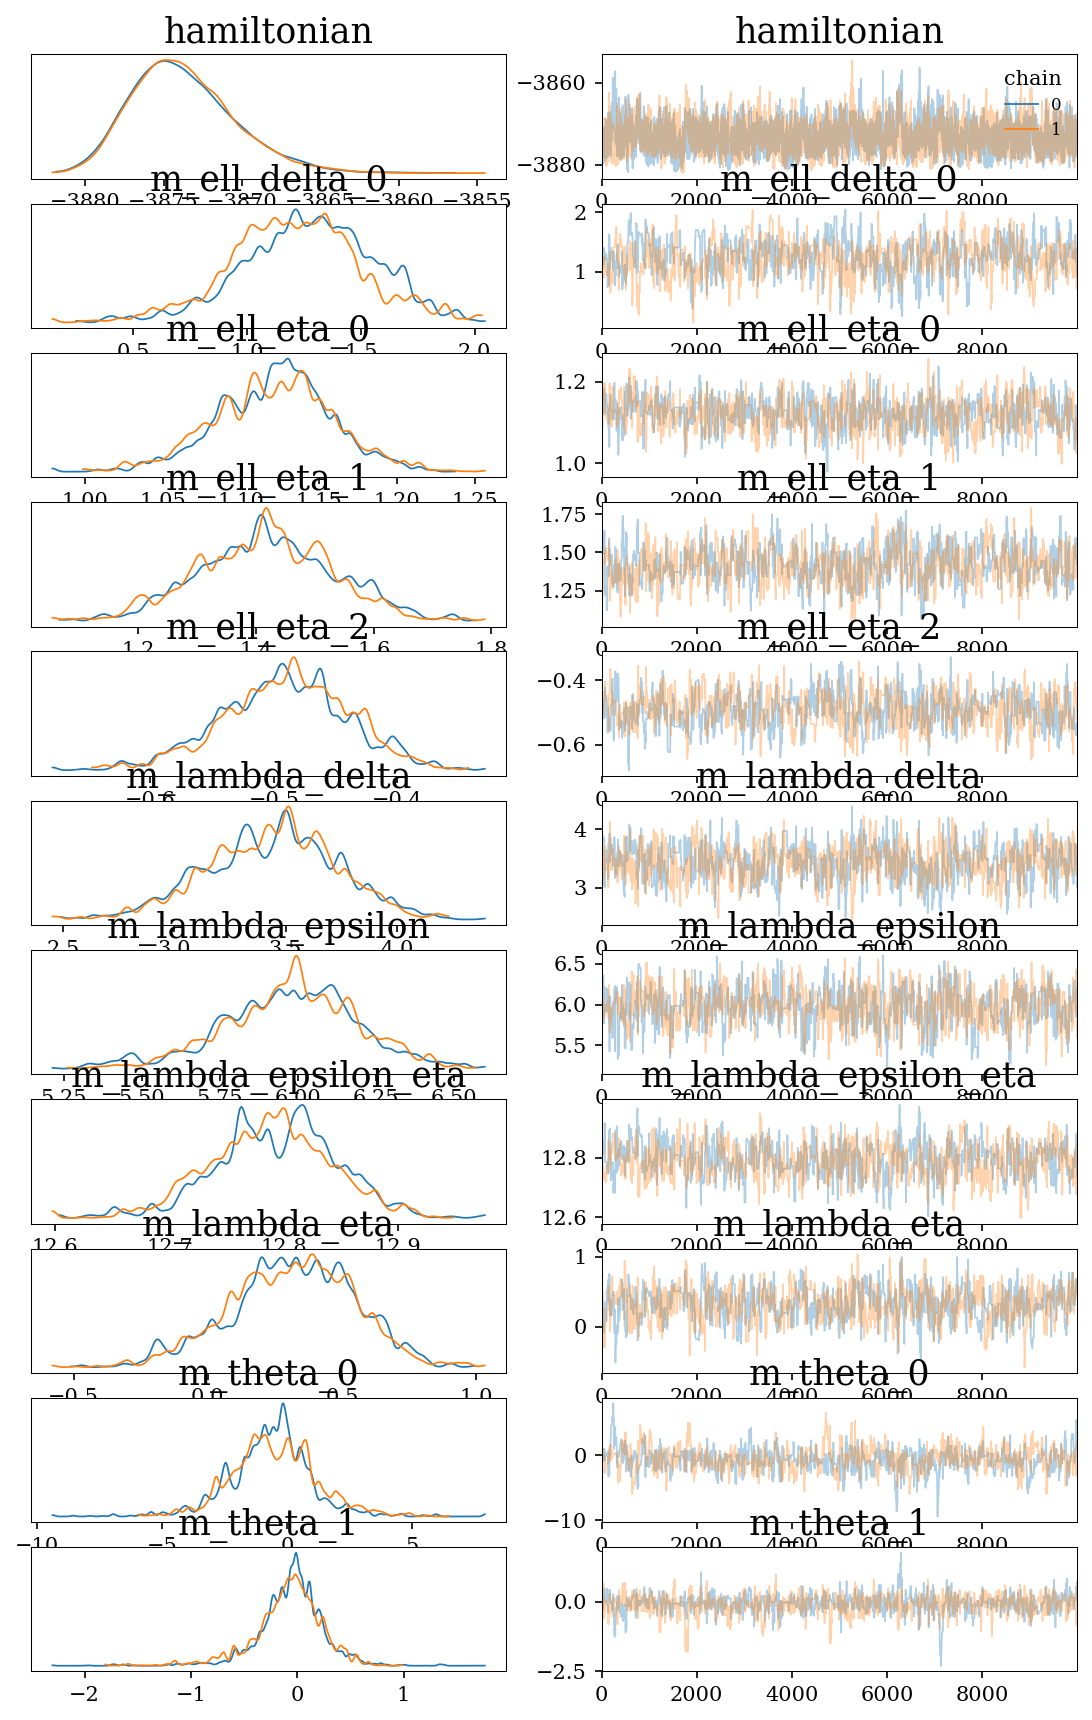

In [12]:
with plt.style.context(plot_style):
    arviz.plot_trace(
        traces,
        # var_names=["σ", "ϵ", "γ", "β", "x_0"],
        figsize=(9, 2 * (7)),
        legend=True,
        compact=False,
    )


## Analyse the transformed MCMC chains

In [13]:
traces_transformed = {}
for var, trace in traces.items():
    if var == 'hamiltonian':
        continue
    var_name = var.split('m_')[1]
    if var_name.startswith('theta'):
        theta_num = int(var_name.split('_')[1])
        traces_transformed[var_name] = mapRto01(trace[0])*(tmax[theta_num]-tmin[theta_num]) + tmin[theta_num]
    elif var_name.startswith('ell'):
        traces_transformed[var_name] = mapRto0inf(trace[0])
    elif var_name.startswith('lambda'):
        traces_transformed[var_name] = mapRto0inf(trace[0])

params_transformed = {}
for var, trace in traces_transformed.items():
    params_transformed[var] = np.mean(trace)
    print(var, ": ", np.mean(trace), '±', np.std(trace))

theta_0 :  0.39195173163646635 ± 0.034800239308607046
theta_1 :  -2.9546558670065175 ± 0.14086569631709364
ell_eta_0 :  3.072032652294873 ± 0.10940457315649589
ell_eta_1 :  4.172839233300354 ± 0.48505854005902616
ell_eta_2 :  0.6119232556941525 ± 0.031886725691621036
ell_delta_0 :  3.7316821068777006 ± 1.052892402591503
lambda_eta :  1.4121605666815256 ± 0.3189619662027369
lambda_delta :  32.52007784541138 ± 9.691298469311972
lambda_epsilon :  401.0550572790188 ± 88.12628621206875
lambda_epsilon_eta :  360725.75606096315 ± 19155.704859518308


In [14]:
arviz.summary(traces_transformed)

Shape validation failed: input_shape: (1, 10000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ell_delta_0,3.732,1.053,1.824,5.676,0.076,0.042,191.0,337.0,NaN
ell_eta_0,3.072,0.109,2.875,3.298,0.006,0.004,292.0,550.0,NaN
ell_eta_1,4.173,0.485,3.338,5.080,0.035,0.019,195.0,299.0,NaN
ell_eta_2,0.612,0.032,0.555,0.673,0.002,0.001,216.0,344.0,NaN
lambda_delta,32.520,9.692,15.458,50.142,0.740,0.358,155.0,293.0,NaN
lambda_epsilon,401.055,88.131,222.886,561.608,5.273,3.500,270.0,296.0,NaN
lambda_epsilon_eta,360725.756,19156.663,329633.969,400854.195,1511.027,719.318,163.0,399.0,NaN
lambda_eta,1.412,0.319,0.811,1.956,0.022,0.011,210.0,279.0,NaN
theta_0,0.392,0.035,0.329,0.444,0.002,0.001,202.0,256.0,NaN
theta_1,-2.955,0.141,-3.215,-2.690,0.009,0.011,319.0,319.0,NaN


**NOTE**: The red priors below are probably different from the priors used above. Please ignore these red priors.

/home/matt/projects/mici-help/.venv/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/traceplot.py:218: UserWarning: A valid var_name should be provided, found {'theta'} expected from {'lambda_epsilon', 'ell_eta_1', 'ell_eta_2', 'ell_delta_0', 'theta_0', 'lambda_epsilon_eta', 'lambda_delta', 'lambda_eta', 'ell_eta_0', 'theta_1'}
  warnings.warn(


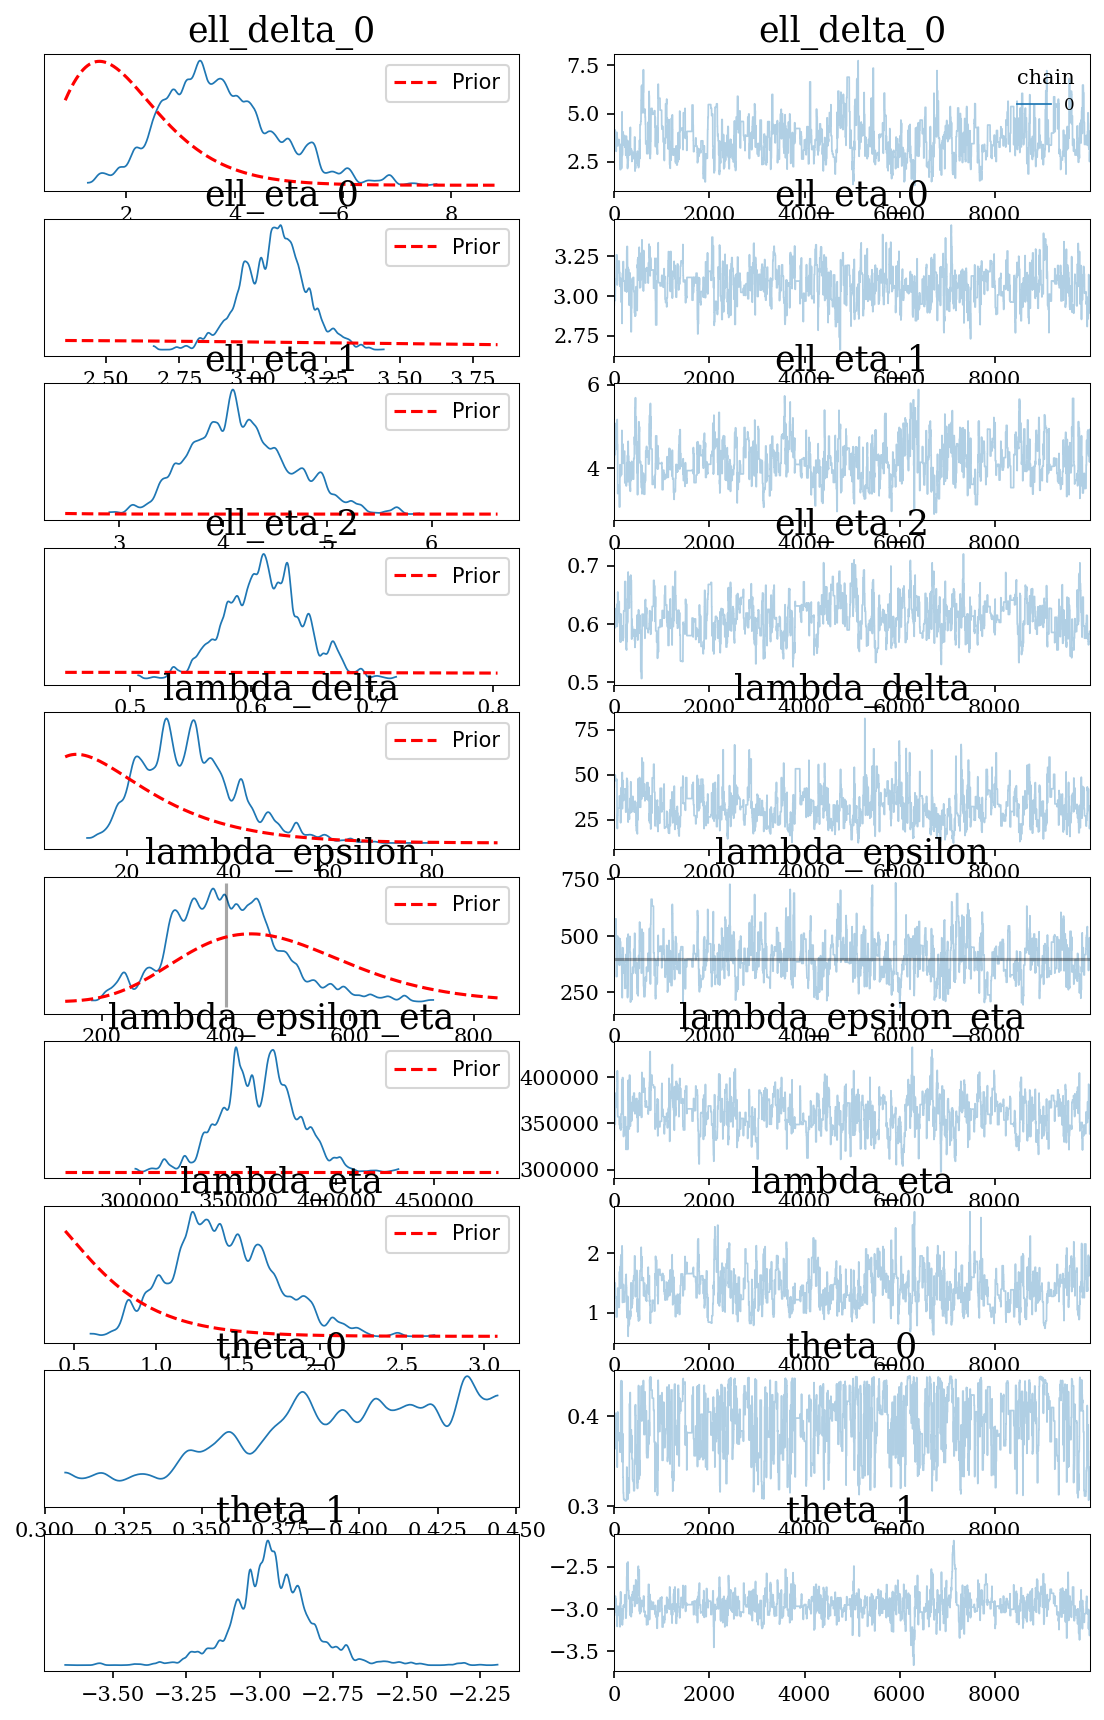

In [15]:
priors = {
    # 'ell_delta_0': [4, 1],
    'ell_delta_0': [4, 2],
    'ell_delta_1': [4, 2],
    'ell_eta_0': [4, 1.4],
    'ell_eta_1': [2, 3.5],
    'ell_eta_2': [2, 2],
    'ell_eta_3': [2, 2],
    # 'lambda_delta': [10, 0.3],
    'lambda_delta': [2, 0.1],
    'lambda_epsilon': [12, 0.025],
    'lambda_epsilon_eta': [10, 0.001],
    'lambda_eta': [2, 4],
}

with plt.style.context(plot_style):
    axes = arviz.plot_trace(
        traces_transformed,
        figsize=(9, 2 * (7)),
        legend=True,
        compact=False,
        lines=(
            ('theta', {}, 0.4),
            ('lambda_epsilon', {}, 1/0.05**2)    
        )
    )
for i in range(axes.shape[0]):
    left, right = axes[i, 0].get_xlim()
    left, right = left*0.9, right*1.1
    x = np.linspace(left, right, 1000)
    title = axes[i, 0].get_title()
    if title in priors:
        alpha, beta = priors[title]
        pdf = gamma.pdf(x, a=alpha, scale=1/beta)
        axes[i, 0].plot(x, pdf, color='red', linestyle='--', label='Prior')
        axes[i, 0].legend()
plt.show()